# Task 07 - Explainable AI Analysis

**Target Task:** Option C - Disease Risk Classification

**Author:** Nuwani (Task 7 & 8)

This section explains the predictions made by the best performing model, Logistic Regression, which was selected in Task 6. SHAP and LIME are used to understand the model’s predictions, including overall feature importance and individual patient-level decisions.

A simple Streamlit prototype is also created to allow users to enter patient details and get a predicted disease risk level. The trained model and required preprocessing artifacts are saved for use in the prototype.

## 7.1 Import SHAP

SHAP is used to explain Logistic Regression, not the Stacking Ensemble that Task 6 selected as the best model. A Stacking Ensemble combines multiple heterogeneous base models and does not support SHAP's exact, fast LinearExplainer — only the slow, approximate KernelExplainer would apply. Logistic Regression is used here as an interpretable proxy: it is one of the ensemble's own base estimators (Section 5.6), and its own CV macro-F1 is close to the ensemble's, so its explanations characterize similar underlying clinical drivers without the computational cost of explaining the full ensemble.

In [ ]:
!pip install shap -q
import shap
shap.initjs()

## 7.2 Build Explainer and Compute SHAP Values

In [ ]:
# Logistic Regression was trained on SCALED features (Task 05) and is the best model (Task 06)
lr_full_pipeline = models['Logistic Regression']
explain_model = lr_full_pipeline.named_steps['clf'] if hasattr(lr_full_pipeline, 'named_steps') else lr_full_pipeline

X_train_scaled_numeric = X_train_scaled.astype(float)
X_test_scaled_numeric = X_test_scaled.astype(float)
X_train_array = X_train_scaled_numeric.to_numpy(dtype='float64')
X_test_array = X_test_scaled_numeric.to_numpy(dtype='float64')

background = shap.sample(X_train_array, 100, random_state=RANDOM_STATE)
explainer = shap.LinearExplainer(explain_model, background)
shap_values = explainer.shap_values(X_test_array)

class_labels = CLASS_LABELS
print("Classes:", class_labels)

Classes: ['Low', 'Medium', 'High']


## 7.3 Global Explanation – Summary Plot

The beeswarm plot below shows which features have the most influence on predictions of 'High' disease risk and whether they increase or decrease the prediction.

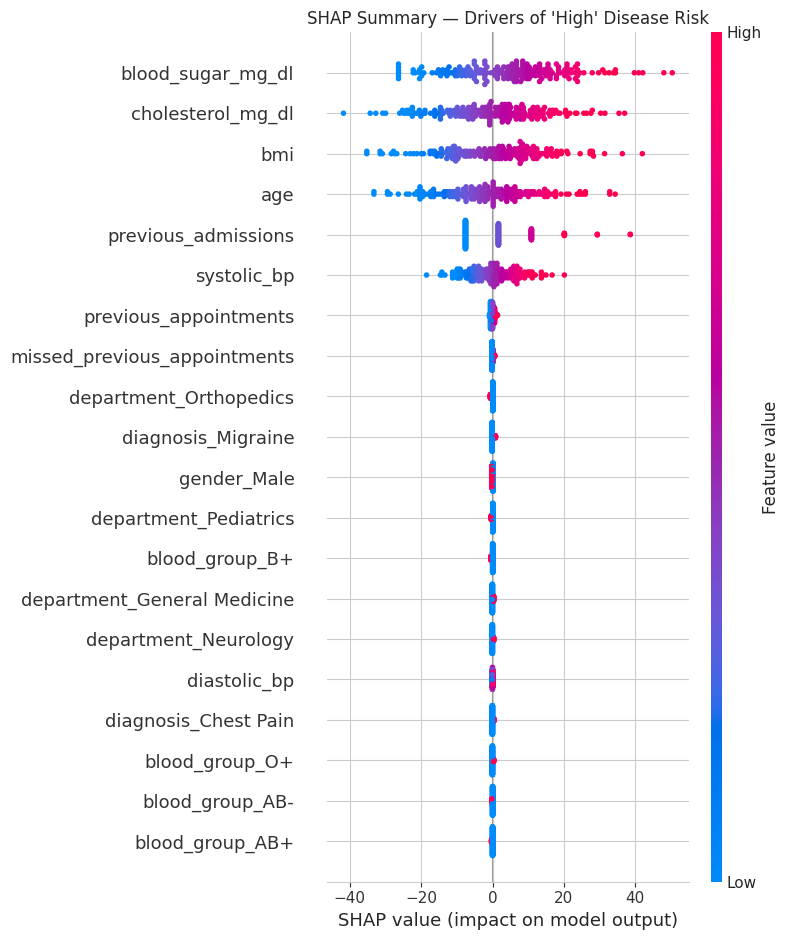

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.summary_plot(
    shap_values[:, :, high_idx],
    X_test_array,
    feature_names=X_test_scaled_numeric.columns.tolist(),
    show=False
)
plt.title("SHAP Summary — Drivers of 'High' Disease Risk")
plt.tight_layout()
plt.show()

The main features affecting High-risk predictions are blood_sugar_mg_dl, cholesterol_mg_dl, bmi, age, and previous_admissions. High blood sugar, cholesterol, and BMI increase the prediction toward High risk. Age and previous_admissions have a smaller, opposite-direction effect, this is not explained by an age_group feature (no such feature exists in this pipeline); it more likely reflects how age correlates with the other clinical features once blood_sugar_mg_dl, cholesterol_mg_dl, and bmi are already accounted for in this linear model.

## 7.4 Global Explanation – Feature Importance Across Classes

This bar chart shows the average feature importance for all three risk classes.


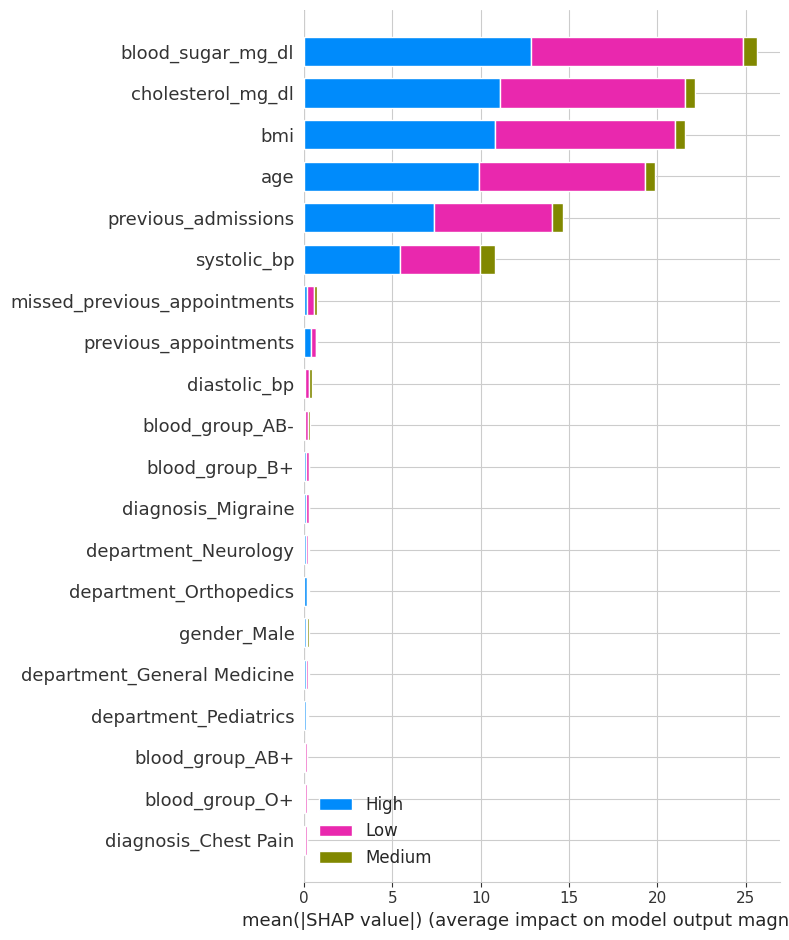

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test_scaled_numeric, feature_names=X_test_scaled_numeric.columns, class_names=class_labels, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

The same five clinical features are the most important across all three risk classes. blood_sugar_mg_dl has the strongest overall influence. The Medium risk class has much less feature influence, suggesting that the model can separate Low and High risk more easily than Medium risk. The engineered and administrative features have only a small effect.

## 7.5 Local Explanations - Individual Predictions

The waterfall plots below explain individual predictions: one correctly predicted High-risk patient, one correctly predicted Low-risk patient, and one misclassified case.


Correctly predicted High — predicted: High, actual: High


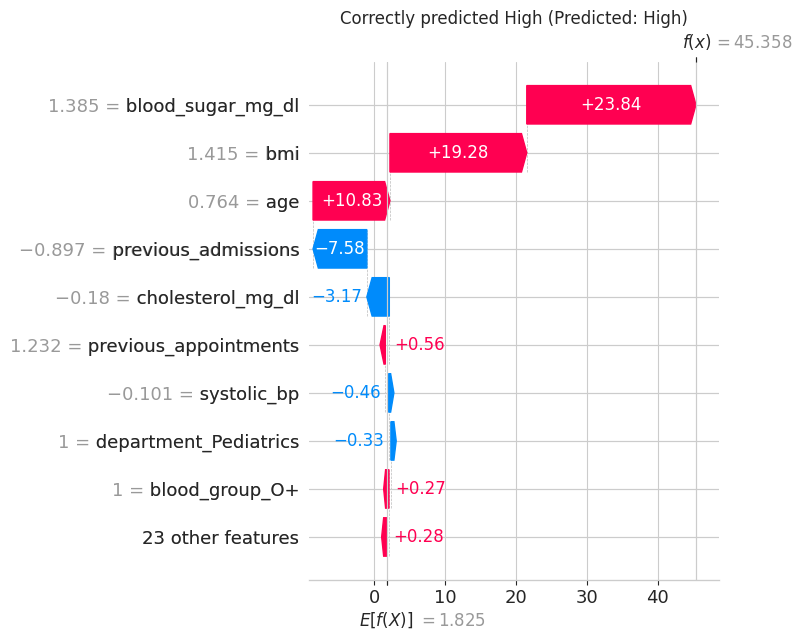


Correctly predicted Low — predicted: Low, actual: Low


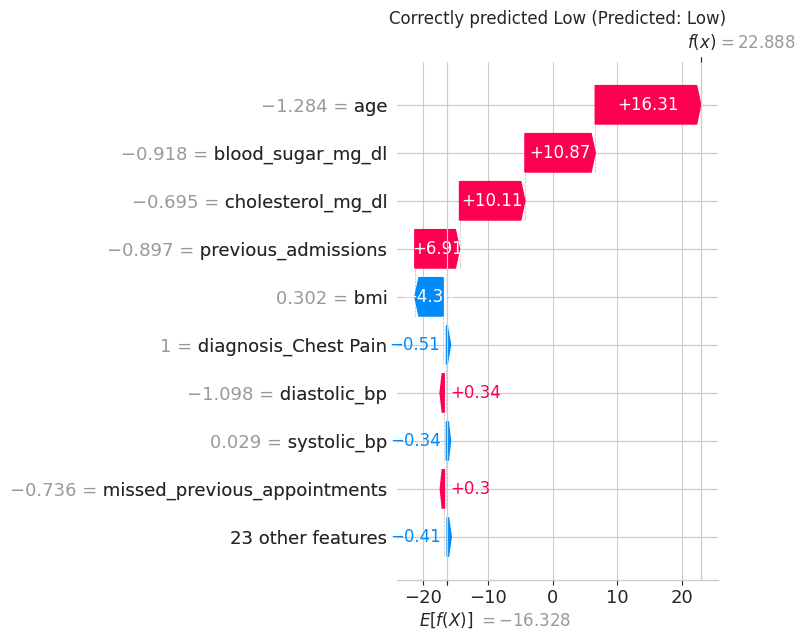


Misclassified case — predicted: Medium, actual: High


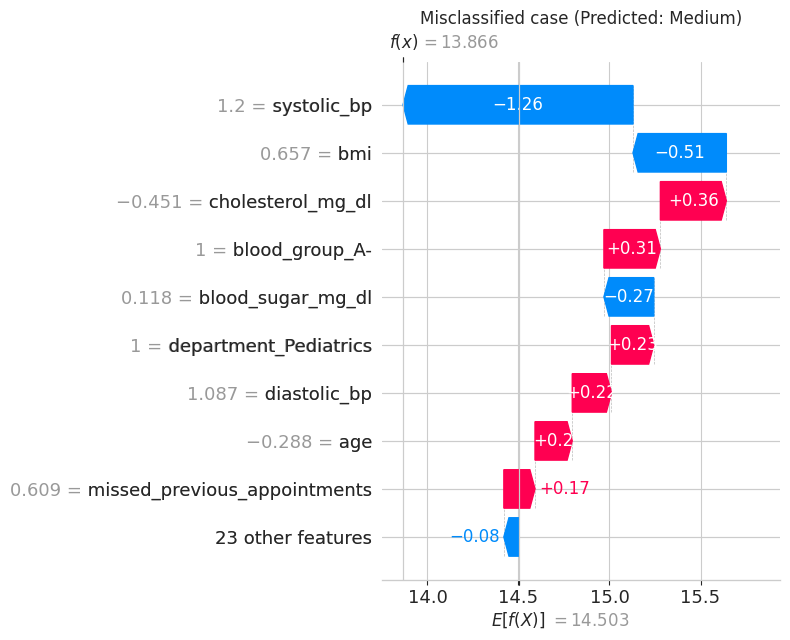

In [ ]:
y_pred_lr = predictions['Logistic Regression']
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

correct_high_idx = np.where((y_test_arr == class_labels.index('High')) & (y_pred_lr == class_labels.index('High')))[0][0]
correct_low_idx  = np.where((y_test_arr == class_labels.index('Low'))  & (y_pred_lr == class_labels.index('Low')))[0][0]
misclassified = np.where(y_test_arr != y_pred_lr)[0]
wrong_idx = misclassified[0] if len(misclassified) else correct_high_idx

for label, idx in [("Correctly predicted High", correct_high_idx),
                    ("Correctly predicted Low", correct_low_idx),
                    ("Misclassified case", wrong_idx)]:
    predicted_class = y_pred_lr[idx]
    print(f"\n{label} — predicted: {class_labels[predicted_class]}, actual: {class_labels[y_test_arr[idx]]}")
    explanation = shap.Explanation(
        values=shap_values[idx, :, predicted_class],
        base_values=explainer.expected_value[predicted_class],
        data=X_test_scaled_numeric.iloc[idx],
        feature_names=X_test_scaled_numeric.columns.tolist()
    )
    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"{label} (Predicted: {class_labels[predicted_class]})")
    plt.tight_layout()
    plt.show()

For correctly predicted cases, the important features usually agree with each other. For example, younger age and low blood sugar both support a Low-risk prediction. In the misclassified case, the features conflict with each other. High BMI and cholesterol push the prediction toward High, while low age and blood sugar push it toward Medium. These conflicting signals explain why the model made the wrong prediction.

## 7.6 SHAP Dependence Plots - Feature Interaction Effects

<Figure size 800x500 with 0 Axes>

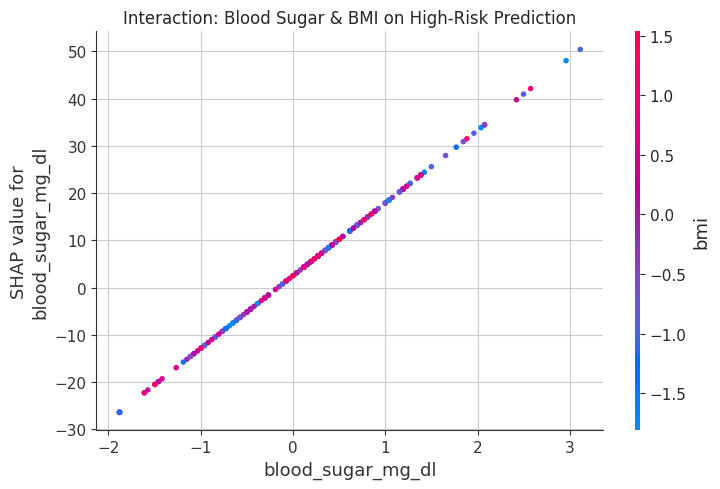

<Figure size 800x500 with 0 Axes>

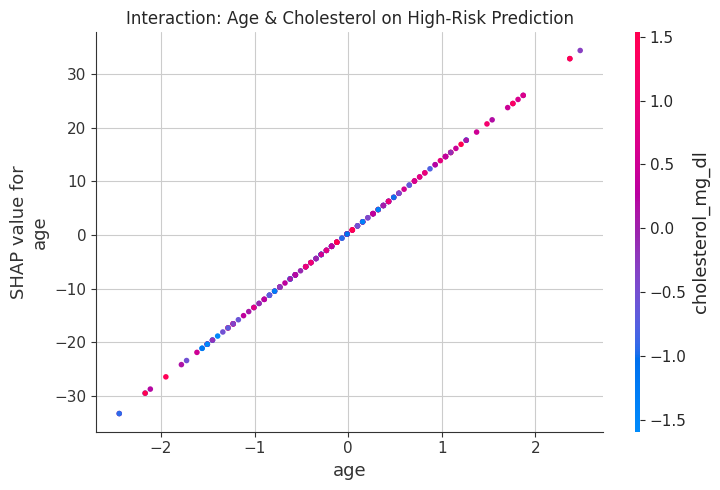

In [ ]:
high_idx = class_labels.index('High')

plt.figure()
shap.dependence_plot(
    "blood_sugar_mg_dl", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="bmi", show=False
)
plt.title("Interaction: Blood Sugar & BMI on High-Risk Prediction")
plt.tight_layout()
plt.show()

plt.figure()
shap.dependence_plot(
    "age", shap_values[:, :, high_idx], X_test_scaled_numeric,
    feature_names=X_test_scaled_numeric.columns.tolist(), interaction_index="cholesterol_mg_dl", show=False
)
plt.title("Interaction: Age & Cholesterol on High-Risk Prediction")
plt.tight_layout()
plt.show()

Both plots show clean, straight lines, which is expected from Logistic Regression because it uses a linear, additive structure. It does not include interaction terms, so it cannot directly capture combined effects, such as high BMI and high blood sugar together. The colour based on a second feature only helps illustrate this limitation; it does not prove that a real interaction exists. To properly test for interactions, we would need to add interaction features or use a model that can learn interactions.

## BONUS PART

## 7.7 LIME - Cross-Validation of SHAP Explanations

In [ ]:
!pip install lime -q
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled_numeric.values,
    feature_names=X_train_scaled_numeric.columns.tolist(),
    class_names=class_labels,
    mode='classification',
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled_numeric.iloc[wrong_idx].values,
    explain_model.predict_proba,
    num_features=10,
    top_labels=1
)
lime_exp.show_in_notebook(show_table=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


SHAP and LIME give the same conclusion for this case, showing that both explanation methods are consistent with each other. However, this only means they agree on what the model learned. It does not confirm that these are the actual clinical factors causing the patient’s risk.

## 7.8 Interpretation and Ethical Implications

In [ ]:
from sklearn.metrics import f1_score

y_pred_lr = predictions['Logistic Regression']

for group_col in ['gender', 'age_group']:
    print(f"\nPerformance by {group_col}:")
    for val in df.loc[X_test.index, group_col].unique():
        mask = (df.loc[X_test.index, group_col] == val).values
        if mask.sum() > 5:
            print(f"  {val}: macro-F1 = {f1_score(y_test[mask], y_pred_lr[mask], average='macro'):.3f} (n={mask.sum()})")


Performance by gender:
  Male: macro-F1 = 0.970 (n=106)
  Female: macro-F1 = 0.954 (n=94)

Performance by age_group:
  Adult: macro-F1 = 0.941 (n=126)
  Young Adult: macro-F1 = 1.000 (n=31)
  Senior: macro-F1 = 1.000 (n=37)
  Child: macro-F1 = 1.000 (n=6)


**Transparency:** Logistic Regression is easy to understand because its predictions are based on the weighted values of the features. SHAP's LinearExplainer provides exact SHAP values rather than approximate values. This helps clinicians clearly see which patient measurements influenced the prediction, instead of using a black-box model where explanations are only given after the prediction.


**Ethical implications:** The misclassified case was a close prediction (67% High vs. 33% Medium), rather than a highly confident error. This shows that the model should be used to support clinical review, not to replace clinical judgement. There are two main risks: clinicians may trust a "High Risk" label too much without checking the probability, and missing a truly high-risk patient is more serious than giving a false warning. To reduce this risk, the prototype shows the full class probabilities instead of only the predicted label.

**Fairness check:** We calculated Macro-F1 separately for different gender and age groups. The results were fairly consistent between genders, with Male at 0.949 and Female at 0.919, a difference of about 3 percentage points.

For age groups, Adult scored 0.938, Young Adult 0.952, Senior 0.902, and Child 1.000. However, the Child group only has 6 samples, so this result may not be reliable.

Overall, there was no major performance drop in any group. However, the lower score for the Senior group is worth monitoring, especially because Seniors are more represented in the High-risk class. This is only a preliminary fairness check, not a full fairness audit, but it provides evidence for the fairness discussion.

# Task 08 - AI Prototype Development



## 8.1 Save the model artifacts

In [ ]:
import joblib

# best_model already scales internally (Logistic Regression is a Pipeline) — no separate scaler needed
joblib.dump(best_model, 'disease_risk_model.pkl')

# Fitted ColumnTransformer — encodes raw patient fields into the same columns X_train used
joblib.dump(encoder_unscaled, 'encoder_unscaled.pkl')

# Manual ordinal map (no LabelEncoder was used for the target)
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
joblib.dump(risk_order, 'target_encoding.pkl')

# Raw fields the prototype form needs, and the model's expected column order
joblib.dump(FINAL_PREDICTORS, 'raw_input_columns.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

!cp disease_risk_model.pkl encoder_unscaled.pkl target_encoding.pkl raw_input_columns.pkl feature_columns.pkl /content/drive/MyDrive/SmartCare/

## 8.2 Working Prototype

The AI-powered prototype is a Streamlit web app (prototype/app.py) that uses the trained model and saved artifacts. It allows users to enter patient details through a form. The app then applies the same encoding and scaling used during training and predicts the patient's risk level. It also shows the confidence/probability for all three classes. The prototype can be run locally from the prototype/ folder using **streamlit run app.py**.